❌ 错误: 未找到文件 fedss_04_herank.csv，请检查当前运行目录下是否存在该文件。


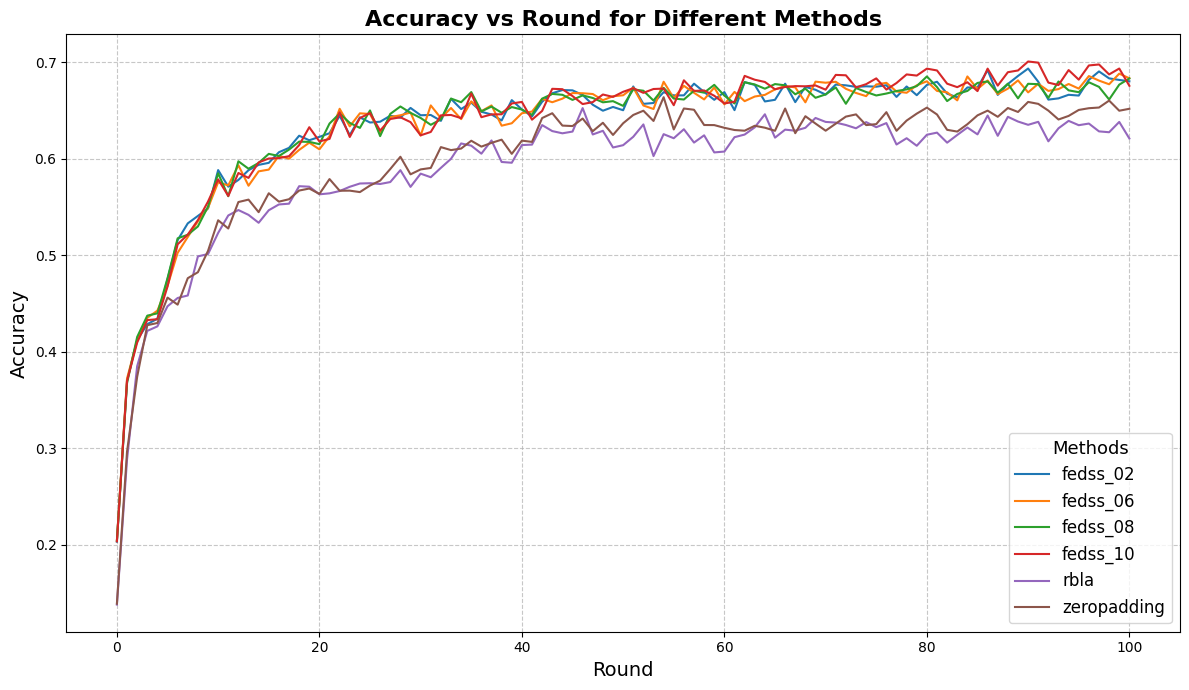

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 定义要读取的文件名及其在图例(Legend)中显示的标签名称
# 注意：fedss_04_herank.csv 遵循了截图中的拼写
file_mapping = {
    "fedss_02_hetrank.csv": "fedss_02",
    "fedss_04_herank.csv": "fedss_04", 
    "fedss_06_hetrank.csv": "fedss_06",
    "fedss_08_hetrank.csv": "fedss_08",
    "flora_hetrank.csv": "fedss_10",
    "rbla_hetrank.csv": "rbla",
    "zeropadding_hetrank.csv": "zeropadding"
}

# 创建图形窗口，设置尺寸
plt.figure(figsize=(12, 7))

# 遍历字典，逐个读取数据并绘图
for file_name, label in file_mapping.items():
    if os.path.exists(file_name):
        # header=1 是为了跳过第一行的 Config 字符串，直接将第二行作为列名
        df = pd.read_csv(file_name, header=1)
        
        # 确认所需列在文件中真实存在后再进行绘制
        if 'round' in df.columns and 'accuracy' in df.columns:
            plt.plot(df['round'], df['accuracy'], label=label, linewidth=1.5)
        else:
            print(f"⚠️ 警告: 文件 {file_name} 中未找到 'round' 或 'accuracy' 列。")
    else:
        print(f"❌ 错误: 未找到文件 {file_name}，请检查当前运行目录下是否存在该文件。")

# 设置图表格式与标签
plt.title("Accuracy vs Round for Different Methods", fontsize=16, fontweight='bold')
plt.xlabel("Round", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)

# 开启网格线，方便对照数值
plt.grid(True, linestyle='--', alpha=0.7)

# 显示图例，并放置在最佳位置
plt.legend(title="Methods", fontsize=12, title_fontsize=13, loc='best')

# 自动调整布局，防止标签被截断
plt.tight_layout()

# 将图片保存到本地（可选）
plt.savefig("accuracy_comparison_plot.png", dpi=300)

# 在屏幕上展示图表
plt.show()